In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# Check data types and look for missing values
print("--- DATASET INFORMATION ---")
df.info()

--- DATASET INFORMATION ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: flo

In [5]:
# Drop columns that are just identifiers and won't help the model
columns_to_drop = ["UDI", "Product ID"]
df_clean = df.drop(columns=columns_to_drop)

# Verify the changes by looking at the first 3 rows
df_clean.head(3)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0


In [6]:
# 1. Check the dimensions of the cleaned dataset (Rows, Columns)
print("--- Current Dimensions ---")
print(f"Rows: {df_clean.shape[0]}, Columns: {df_clean.shape[1]}")

# 2. Define a dictionary to rename columns into a cleaner format
rename_dict = {
    "Type": "type",
    "Air temperature [K]": "air_temperature",
    "Process temperature [K]": "process_temperature",
    "Rotational speed [rpm]": "rotational_speed",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "tool_wear",
    "Machine failure": "machine_failure",
    "TWF": "twf",
    "HDF": "hdf",
    "PWF": "pwf",
    "OSF": "osf",
    "RNF": "rnf"
}
# 3. Apply the renaming to the dataset
df_clean = df_clean.rename(columns=rename_dict)

# 4. Display the first 2 rows to confirm the new names
df_clean.head(2)

--- Current Dimensions ---
Rows: 10000, Columns: 12


,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure,twf,hdf,pwf,osf,rnf
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0


In [7]:
# Count how many times the machine failed vs. operated normally
failure_counts = df_clean["machine_failure"].value_counts()
print("--- FAILURE COUNT (0 = Normal, 1 = Failure) ---")
print(failure_counts)

# Calculate the percentage of failures in the dataset
failure_percentage = df_clean["machine_failure"].value_counts(normalize=True) * 100
print("\n--- FAILURE PERCENTAGE ---")
print(failure_percentage)


--- FAILURE COUNT (0 = Normal, 1 = Failure) ---
machine_failure
0    9661
1     339
Name: count, dtype: int64

--- FAILURE PERCENTAGE ---
machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [8]:
# list of failure modes 
failure_modes = ['twf','hdf','pwf','osf','rnf']

# Sum each column to find the total ocurrences of each mode
failure_summary = df_clean[failure_modes].sum()

print('---Breakdown of failure modes---')
print(failure_summary)

---Breakdown of failure modes---
twf     46
hdf    115
pwf     95
osf     98
rnf     19
dtype: int64


In [9]:
# Sensor features 
sensor_features = ['air_temperature','process_temperature','rotational_speed','torque','tool_wear']
sensor_stats = df_clean[sensor_features].describe()

# descriptive statistics for the sensors
sensor_stats

,air_temperature,process_temperature,rotational_speed,torque,tool_wear
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


In [10]:
# Pearson's correlation matrix to normalize the dimension of the data
correlation_matrix = df_clean[sensor_features].corr()
correlation_matrix

,air_temperature,process_temperature,rotational_speed,torque,tool_wear
air_temperature,1.000000,0.876107,0.022670,-0.013778,0.013853
process_temperature,0.876107,1.000000,0.019277,-0.014061,0.013488
rotational_speed,0.022670,0.019277,1.000000,-0.875027,0.000223
torque,-0.013778,-0.014061,-0.875027,1.000000,-0.003093
tool_wear,0.013853,0.013488,0.000223,-0.003093,1.000000


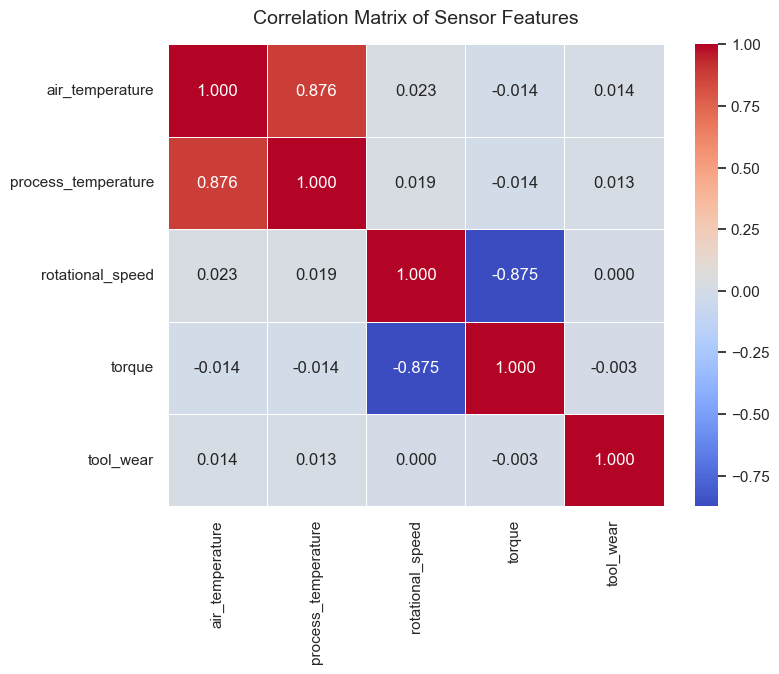

In [11]:
# Graphics for better visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.set_theme(style="white")
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5)
plt.title("Correlation Matrix of Sensor Features", fontsize=14, pad=15)
plt.savefig('images/sensor_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# 1) calculating Delta-T as instructed by the databank Kaggle and the authors of the data-set
df_clean['temperature_difference'] = df_clean['process_temperature'] - df_clean['air_temperature']
# 2) Calculating a proxy for Power [Torque X speed] / Power is related to mechanical and eletrical stress
df_clean['power_proxy'] = df_clean['torque'] * df_clean['rotational_speed']
# 3 ) Check the new data frame for the new columns we just created 
df_clean[['temperature_difference','power_proxy']].head(3)

,temperature_difference,power_proxy
0,10.5,66382.8
1,10.5,65190.4
2,10.4,74001.2


In [13]:
# Now we create a dictionary to transform the type of materials into numbers (or levels if you will)
type_mapping = {"L" : 0 , "M" : 1, "H" : 2}
# map the values in the dataframe with our dictionary
df_clean['type'] = df_clean['type'].map(type_mapping)
# check if it worked 
df_clean['type'].head()

0    1
1    0
2    0
3    0
4    0
Name: type, dtype: int64

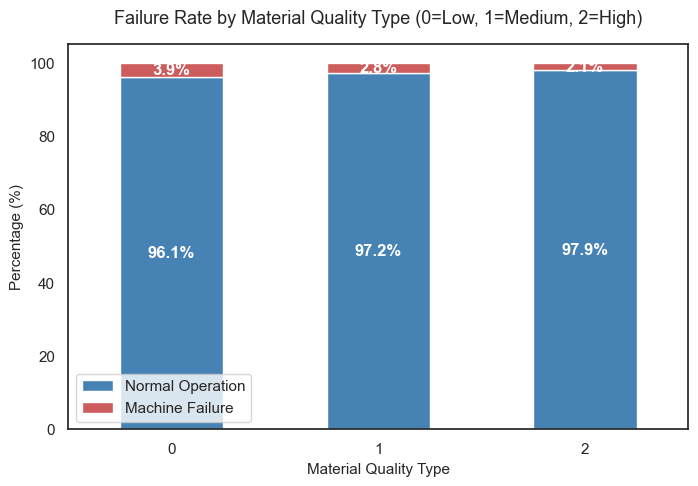

In [14]:
# 1) Create a cross-tabulation of material vs machine failure
cross_tab = pd.crosstab(df_clean['type'], df_clean['machine_failure'], normalize='index') * 100

# 2) Plot a stacked bar chart [0] = normal function, [1] = failure
ax = cross_tab.plot(kind = 'bar', stacked = True, figsize = (8,5), color = ['#4682B4', "#CD5C5C"])

# 3) customize the labels for a better look
plt.title("Failure Rate by Material Quality Type (0=Low, 1=Medium, 2=High)", fontsize=13, pad=15)
plt.xlabel("Material Quality Type", fontsize=11)
plt.ylabel("Percentage (%)", fontsize=11)
plt.xticks(rotation=0)
plt.legend(["Normal Operation", "Machine Failure"], loc="lower left")

# 4) Add the numbers for readability
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", color="white", weight="bold")

plt.show()


In [15]:
from sklearn.preprocessing import StandardScaler

# 1) make a list of all sensor and sensor-derived columns that will be normalized
features_to_scale = ['air_temperature','process_temperature','rotational_speed','torque','tool_wear','temperature_difference','power_proxy']

# 2) Initiate the object that Z-score the variables
scaler = StandardScaler()

# 3) Scale a copy of the original dataframe
df_scaled = df_clean.copy()

# 4) Fit and transform 
df_scaled[features_to_scale] = scaler.fit_transform(df_clean[features_to_scale])

# 5) Display the head of the new dataframe to see if it worked
df_scaled[features_to_scale].head(3)


,air_temperature,process_temperature,rotational_speed,torque,tool_wear,temperature_difference,power_proxy
0,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0.498849,0.629443
1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0.498849,0.512456
2,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0.398954,1.376889


In [16]:
# 1) define our X and y, by selecting the features we want to analise 
# we remove the modes of failure for now so our model doesn't "cheat" (from 'X' of course)
columns_to_exclude = ['machine_failure','twf','hdf','pwf','osf','rnf']
X = df_scaled.drop(columns = columns_to_exclude)

# 2) Define our target variable (it's a binary)
y = df_scaled['machine_failure']

# 3) Verify the shapes of the new matrixes (output = tuples)
print(f'X Shape (Features Matrix) {X.shape}')
print(f'Y Shape (Target Vector) {y.shape}')

X Shape (Features Matrix) (10000, 8)
Y Shape (Target Vector) (10000,)


In [17]:
# Data splitting and start of the model per se.
from sklearn.model_selection import train_test_split

# we will split in 80% training 20% test, and use stratify to equally distribute the few failures (about 3% of machines fail)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20, random_state = 42, stratify = y)

# verify the dimensions
print(' --- Training Set Shape --- ')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')

print('\n --- Test Set Shape ---')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')


 --- Training Set Shape --- 
X_train: (8000, 8), y_train: (8000,)

 --- Test Set Shape ---
X_test: (2000, 8), y_test: (2000,)


In [18]:
# Trying Logistic Regression Model.
from sklearn.linear_model import LogisticRegression

# 1) Initialize: we use balance because of the low amount of failures 
model = LogisticRegression(class_weight = 'balanced', random_state = 42)

# 2) train the model
model.fit(X_train, y_train)
print("--- Model Trained sucessfully ---")

--- Model Trained sucessfully ---


In [19]:
# 1) Now, the predictions
y_pred = model.predict(X_test)

# 2) Display the first predictions
print(" --- First 30 predictions (0 = Normal, 1 = Failure ) ---")
print(y_pred[:30])

# 3) Display the first 30 real answers to compare
print("\n--- First 30 real answers ---")
print(y_test.values[:30])

 --- First 30 predictions (0 = Normal, 1 = Failure ) ---
[1 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0]

--- First 30 real answers ---
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0]


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
# generate performance matrix for all the 2000 test rows

cm = confusion_matrix(y_test, y_pred)
print('--- Confusion Matrix ---')
print(cm)

print('--- Classification Report ---')
print(classification_report(y_test, y_pred))

# Support = 68 real failures .. recall 0.87 / 87% of the failures (59) were predicted

--- Confusion Matrix ---
[[1656  276]
 [   9   59]]
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1932
           1       0.18      0.87      0.29        68

    accuracy                           0.86      2000
   macro avg       0.59      0.86      0.61      2000
weighted avg       0.97      0.86      0.90      2000



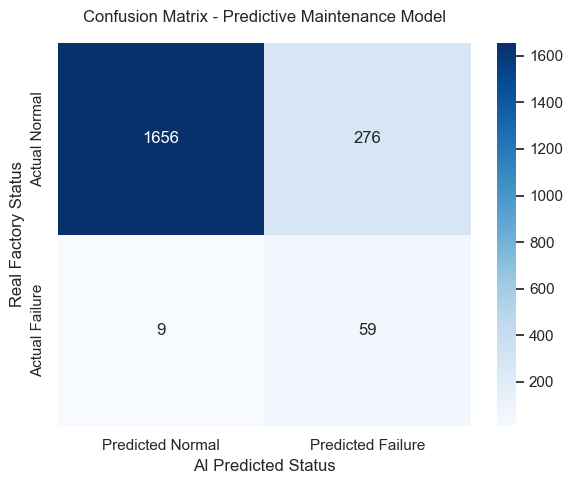

In [24]:
# visualisation of the confusion matrix with heatmap
plt.figure(figsize = (6,5))
sns.heatmap(cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=["Predicted Normal", "Predicted Failure"],
    yticklabels=["Actual Normal", "Actual Failure"])

# titles and labels
plt.title("Confusion Matrix - Predictive Maintenance Model", fontsize=12, pad=15)
plt.ylabel("Real Factory Status")
plt.xlabel("AI Predicted Status")
plt.tight_layout()
plt.savefig('images/confusion_matrix_logistic_regression.png', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
# Ok , lets try now the tried and true Decision tree for the sake of comparison
from sklearn.ensemble import RandomForestClassifier
# 1) Initialize it
rf_model = RandomForestClassifier(class_weight = "balanced", random_state = 42, n_estimators = 100)

# 2) Train it
rf_model.fit(X_train, y_train)

# 3) Prediction
y_pred_rf = rf_model.predict(X_test)

# 4) Display the results
print("--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.96      0.66      0.78        68

    accuracy                           0.99      2000
   macro avg       0.97      0.83      0.89      2000
weighted avg       0.99      0.99      0.99      2000



In [23]:
# precision : Now we have 96% against the 18% from LR model (less false alarms)
# but recall was a little worse (the model let 34% of failures undetected)

# in resume : Logistic Regression is more safe and conservative, but means more process interruptions